# Mini-Project 2 — Solar Micro-Grid Dispatch Planner

**Scenario.** A rural health centre in Kasese runs a micro-grid. Each day the energy drawn from solar panels ($x$) and batteries ($y$) must satisfy

$$3x + 2y = D_1 \quad\text{(daytime load, kWh)}\qquad 4x + y = D_2 \quad\text{(critical-equipment load, kWh)}$$

The logic lives in [`src/microgrid.py`](src/microgrid.py):

| Class / function | Responsibility | OOP idea |
|---|---|---|
| `MicroGrid` | Holds the coefficient matrix, checks well-posedness, solves (loop / vectorised), repairs infeasible days, costs, sensitivity | Encapsulation (read-only matrix), `__repr__` |
| `HybridMicroGrid(MicroGrid)` | Adds diesel and a third constraint; diagnoses linearly dependent constraints | Inheritance, `super().__init__`, class method constructor |
| `DemandSeries` | Validated daily demands; synthetic generator, CSV writer and reader | Alternative constructors (`@classmethod`), `__len__`, `__getitem__` |
| `DispatchPlan`, `SensitivityResult` | Result objects with derived properties (feasibility mask, amplification) | Dataclasses |
| `parse_demand`, `prompt_demand` | Robust input with re-prompting; the `input` function is injected | Dependency injection (testable I/O) |

### Assumptions
1. The coefficients are taken as given. I read them as a stylised accounting model: each kWh drawn from a source serves the two load "accounts" with those weights. $x$ and $y$ are energy drawn (kWh), so they must be $\ge 0$.
2. Demand data are **synthetic but structured** (seed 2026). Daytime load $D_1$ follows clinic activity: slightly higher on Monday, lower on Saturday (× 0.85) and lowest on Sunday (× 0.72, outpatients closed). Critical load $D_2$ (vaccine fridges, oxygen concentrators, theatre lighting) is roughly flat all week. Noise is Gaussian: 4 % on $D_1$ and 3 % on $D_2$.
3. Costs are illustrative: solar UGX 150/kWh and battery UGX 450/kWh (plus diesel UGX 1,200/kWh in the extension).
4. **A health centre must never short its critical equipment.** This principle drives the choice of repair strategy for infeasible days.

In [1]:
import statistics
import timeit
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg

from src.microgrid import (
    MicroGrid, HybridMicroGrid, DemandSeries, SingularSystemError, parse_demand, prompt_demand,
)

SEED = 2026
rng = np.random.default_rng(SEED)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
DATA_PATH = Path("data/kasese_demand.csv")
INTERACTIVE = False   # set True to type demands yourself in Task 2(a)

## Task 1 — The `MicroGrid` class and a well-posedness check

In [2]:
grid = MicroGrid()   # defaults: A = [[3, 2], [4, 1]], solar 150, battery 450 UGX/kWh
print(grid)
print("A =\n", grid.coefficients)
wp = grid.well_posedness()
wp

MicroGrid(sources=['solar', 'battery'], det=-5, cond=5.83)
A =
 [[3. 2.]
 [4. 1.]]


{'determinant': -4.999999999999999,
 'condition_number': 5.82842712474619,
 'rank': 2,
 'well_posed': True}

In [3]:
# Second-method checks
A = grid.coefficients
det_hand = A[0, 0] * A[1, 1] - A[0, 1] * A[1, 0]
sing = np.linalg.svd(A, compute_uv=False)
print(f"det by hand: 3*1 - 2*4 = {det_hand:.0f}")
print(f"singular values: {sing.round(4)}  ->  cond = {sing[0]:.4f} / {sing[1]:.4f} = {sing[0] / sing[1]:.4f}")

x, y = grid.solve_day(95, 100)
print(f"\nExample day D1=95, D2=100 -> solar x = {x:.2f} kWh, battery y = {y:.2f} kWh")
print("Cramer's rule: x = (2*D2 - D1)/5 =", (2 * 100 - 95) / 5, "| y = (4*D1 - 3*D2)/5 =", (4 * 95 - 3 * 100) / 5)

det by hand: 3*1 - 2*4 = -5
singular values: [5.3983 0.9262]  ->  cond = 5.3983 / 0.9262 = 5.8284

Example day D1=95, D2=100 -> solar x = 21.00 kWh, battery y = 16.00 kWh
Cramer's rule: x = (2*D2 - D1)/5 = 21.0 | y = (4*D1 - 3*D2)/5 = 16.0


**What the two numbers mean.**

* **Determinant = −5 (non-zero).** The two constraint lines are not parallel, so for *any* pair of demands there is **exactly one** $(x, y)$. The sign only says the two columns are ordered "clockwise"; it has no physical meaning. The size of the determinant alone is *not* a good guide to stability, because scaling every coefficient by 10 multiplies it by 100 without changing the geometry.
* **Condition number ≈ 5.83.** This is the ratio of the largest to the smallest singular value. It bounds how much a *relative* error in the demands can be magnified in the solution: $\frac{\|\delta s\|}{\|s\|} \le \kappa\,\frac{\|\delta d\|}{\|d\|}$. A 1 % metering error in $D_1, D_2$ can therefore move $(x, y)$ by at most about 5.8 %. That is **well-conditioned**: we lose less than one significant digit ($\log_{10}5.8 \approx 0.8$). Trouble starts when κ approaches 10⁶ or more, and κ = ∞ means the matrix is singular.

The solution can be written in closed form (Cramer's rule): $x = (2D_2 - D_1)/5$ and $y = (4D_1 - 3D_2)/5$. So **both sources are non-negative only if $0.75 \le D_1/D_2 \le 2$**. This single inequality explains every infeasible day found below.

## Task 2 — Two input modes

### (a) Interactive input with validation
`prompt_demand` loops until `parse_demand` accepts the text. It rejects empty strings, non-numbers, NaN/inf and negatives, and re-prompts with a reason each time. Because the input function is a parameter, the same code is demonstrated below with scripted answers (so *Restart & Run All* never blocks), and it is unit-tested. Set `INTERACTIVE = True` in the setup cell to type values yourself.

In [4]:
if INTERACTIVE:
    d1 = prompt_demand("Daytime load D1 (kWh): ")
    d2 = prompt_demand("Critical load D2 (kWh): ")
else:
    scripted = iter(["", "ninety", "-40", "95.5",      # D1: three bad answers, then a good one
                     "nan", "   ", "1,00", "100"])      # D2: NaN, blank, then valid values
    fake_input = lambda prompt: (lambda ans: (print(f"{prompt}{ans!r}"), ans)[1])(next(scripted))
    d1 = prompt_demand("Daytime load D1 (kWh): ", input_fn=fake_input)
    d2 = prompt_demand("Critical load D2 (kWh): ", input_fn=fake_input)

print(f"\nAccepted D1 = {d1}, D2 = {d2}")
print("Dispatch:", dict(zip(grid.sources, grid.solve_day(d1, d2).round(2))))

Daytime load D1 (kWh): ''
  Invalid input: Empty input - please type a number. Try again.
Daytime load D1 (kWh): 'ninety'
  Invalid input: 'ninety' is not a number. Try again.
Daytime load D1 (kWh): '-40'
  Invalid input: Demand cannot be negative. Try again.
Daytime load D1 (kWh): '95.5'
Critical load D2 (kWh): 'nan'
  Invalid input: Demand must be a finite number. Try again.
Critical load D2 (kWh): '   '
  Invalid input: Empty input - please type a number. Try again.
Critical load D2 (kWh): '1,00'

Accepted D1 = 95.5, D2 = 100.0
Dispatch: {'solar': np.float64(20.9), 'battery': np.float64(16.4)}


Each rejection prints the reason and asks again. `"1,00"` is accepted as 100 because commas are treated as thousands separators, so the loop stops there and the final `"100"` is never read. Validation checks only that the *input* is a legal non-negative number; whether the *system* has a physically meaningful answer for it is a separate question (Task 4).

### (b) 30 days from a CSV file (generated with a seeded RNG)

In [5]:
generated = DemandSeries.synthetic(n_days=30, seed=SEED)
generated.to_csv(DATA_PATH)
demand = DemandSeries.from_csv(DATA_PATH)          # read back through the validating loader
print(demand)
print(DATA_PATH.read_text().splitlines()[:4])
assert np.allclose(demand.rhs, generated.rhs)

df = pd.DataFrame({"weekday": demand.weekdays, "D1 (kWh)": demand["d1_kwh"], "D2 (kWh)": demand["d2_kwh"]},
                  index=pd.Index(demand.dates, name="date"))
df["D1/D2"] = df["D1 (kWh)"] / df["D2 (kWh)"]
df.groupby("weekday", sort=False)[["D1 (kWh)", "D2 (kWh)", "D1/D2"]].mean()

DemandSeries(2026-09-01 to 2026-09-30, days=30, columns=['d1_kwh', 'd2_kwh'])
['date,weekday,d1_kwh,d2_kwh', '2026-09-01,Tue,91.99,96.49', '2026-09-02,Wed,95.91,104.05', '2026-09-03,Thu,87.79,102.50']


,D1 (kWh),D2 (kWh),D1/D2
weekday,,,
Tue,94.32,100.65,0.94
Wed,94.47,100.81,0.94
Thu,92.46,103.66,0.89
Fri,100.11,100.06,1.00
Sat,83.05,100.77,0.83
Sun,66.73,102.04,0.66
Mon,100.22,102.12,0.98


The loader refuses a corrupted file and names the offending line:

In [6]:
bad = Path("data/_bad_demand.csv")
bad.write_text("date,d1_kwh,d2_kwh\n2026-09-01,95,100\n2026-09-02,abc,100\n")
try:
    DemandSeries.from_csv(bad)
except ValueError as err:
    print("ValueError:", err)
finally:
    bad.unlink()

ValueError: Line 3, column 'd1_kwh': 'abc' is not a number.


## Task 3 — Solve all 30 days: loop vs one vectorised call

In [7]:
rhs = demand.rhs                     # shape (2, 30)
loop_sol = grid.solve_loop(rhs)      # 30 calls to scipy.linalg.solve
vec_sol = grid.solve_vectorised(rhs) # 1 call with a 2 x 30 right-hand side
assert np.allclose(loop_sol, vec_sol)
print("Max difference between the two methods:", np.abs(loop_sol - vec_sol).max())

def time_it(fn, arg, number=50, repeat=5):
    return min(timeit.repeat(lambda: fn(arg), number=number, repeat=repeat)) / number

rows = []
for n_days in (30, 300, 3000):
    big = np.tile(rhs, (1, n_days // 30))
    t_loop, t_vec = time_it(grid.solve_loop, big, number=5), time_it(grid.solve_vectorised, big, number=5)
    rows.append({"days": n_days, "loop (ms)": t_loop * 1e3, "vectorised (ms)": t_vec * 1e3, "speed-up (x)": t_loop / t_vec})
timing = pd.DataFrame(rows).set_index("days")
timing

Max difference between the two methods: 3.552713678800501e-15


,loop (ms),vectorised (ms),speed-up (x)
days,,,
30,0.90,0.08,11.39
300,8.60,0.09,100.00
3000,83.48,0.14,604.96


Both methods give identical answers (to rounding error), but the vectorised call is roughly **an order of magnitude faster for 30 days**, and the gap widens to hundreds of times as the number of days grows. Exact timings depend on the machine; the pattern does not.

The reason is not the arithmetic: solving a 2×2 system takes a handful of floating-point operations. The cost is **per-call overhead**: Python function dispatch, SciPy's input checks (`check_finite`, shape checks) and the LAPACK call setup. The loop pays this overhead 30 times. The vectorised call pays it once, factorises $A$ once (LU), and then reuses the factors for all 30 right-hand sides inside compiled code. Its time is almost flat from 30 to 3,000 days.

The lesson generalises: when the matrix is fixed and only the demands change, **factorise once and solve many** (`scipy.linalg.lu_factor` / `lu_solve` does the same thing explicitly).

## Task 4 — Detect and handle physically infeasible days

In [8]:
raw_plan = grid.dispatch(rhs, strategy="none")
bad_days = raw_plan.infeasible_days
flagged = pd.DataFrame({
    "weekday": [demand.weekdays[i] for i in bad_days],
    "D1": rhs[0, bad_days], "D2": rhs[1, bad_days], "D1/D2": rhs[0, bad_days] / rhs[1, bad_days],
    "raw solar x": raw_plan.raw[0, bad_days], "raw battery y": raw_plan.raw[1, bad_days],
}, index=pd.Index([demand.dates[i] for i in bad_days], name="date"))
print(f"{len(bad_days)} of {len(raw_plan)} days are infeasible (negative battery draw):")
flagged

5 of 30 days are infeasible (negative battery draw):


,weekday,D1,D2,D1/D2,raw solar x,raw battery y
date,,,,,,
2026-09-06,Sun,67.60,102.05,0.66,27.30,-7.15
2026-09-13,Sun,68.22,97.52,0.70,25.36,-3.94
2026-09-19,Sat,80.33,107.68,0.75,27.01,-0.34
2026-09-20,Sun,64.64,109.45,0.59,30.85,-13.96
2026-09-27,Sun,66.45,99.13,0.67,26.36,-6.32


Every flagged day has $D_1/D_2 < 0.75$: the four **Sundays** and **Saturday 19 September** (a noisy day with high critical load). When outpatient activity falls but the critical equipment keeps running, the only way to satisfy both *equalities* is to draw a **negative** amount from the battery. In reality that would mean charging it, but the model defines $y$ as energy drawn.

I implemented three repair strategies. Each touches only the infeasible days:

* **clip** — set negatives to 0 and keep the other value (simple, but ignores the equations);
* **nnls** — `scipy.optimize.nnls`: the non-negative $(x, y)$ that comes closest to satisfying both equations in a least-squares sense;
* **cover** — `scipy.optimize.linprog`: the *cheapest* non-negative dispatch with $A s \ge d$, so every load is met and any surplus is curtailed.

In [9]:
compare = []
for strategy in ("clip", "nnls", "cover"):
    plan = grid.dispatch(rhs, strategy)
    r = plan.residual[:, bad_days]            # demand - supplied; >0 unmet, <0 surplus
    compare.append({
        "strategy": strategy,
        "unmet daytime (kWh)": np.clip(r[0], 0, None).sum(),
        "unmet CRITICAL (kWh)": np.clip(r[1], 0, None).sum(),
        "surplus / curtailed (kWh)": -np.clip(r, None, 0).sum(),
        "cost of the 5 days (UGX)": grid.daily_cost(plan.adjusted[:, bad_days]).sum(),
    })
pd.DataFrame(compare).set_index("strategy")

,unmet daytime (kWh),unmet CRITICAL (kWh),surplus / curtailed (kWh),cost of the 5 days (UGX)
strategy,,,,
clip,0.00,0.00,95.12,"20,532.60"
nnls,0.00,19.02,25.36,"18,630.24"
cover,0.00,0.00,39.63,"19,343.62"


**Choice: `cover` (now the default).** NNLS is the textbook fix and is the cheapest, but it achieves that by leaving about **19 kWh of critical load unmet** over the five days. For a health centre that could mean a vaccine fridge or an oxygen concentrator losing power, which is unacceptable. Clipping meets every load but wastes about 95 kWh. `cover` meets every load with less than half that surplus, at a cost between the other two. The surplus is modest and could in practice be used to charge the battery.

In [10]:
plan = grid.dispatch(rhs, strategy="cover")
report = pd.DataFrame({
    "raw x": plan.raw[0, bad_days], "raw y": plan.raw[1, bad_days],
    "adjusted x": plan.adjusted[0, bad_days], "adjusted y": plan.adjusted[1, bad_days],
    "daytime surplus (kWh)": -plan.residual[0, bad_days], "critical shortfall (kWh)": plan.residual[1, bad_days].clip(0),
}, index=pd.Index([demand.dates[i] for i in bad_days], name="date"))
report

,raw x,raw y,adjusted x,adjusted y,daytime surplus (kWh),critical shortfall (kWh)
date,,,,,,
2026-09-06,27.30,-7.15,25.51,0.00,8.94,0.00
2026-09-13,25.36,-3.94,24.38,0.00,4.92,0.00
2026-09-19,27.01,-0.34,26.92,0.00,0.43,0.00
2026-09-20,30.85,-13.96,27.36,0.00,17.45,0.00
2026-09-27,26.36,-6.32,24.78,0.00,7.90,0.00


On every repaired day the cheapest cover is **solar only**: $x = \max(D_1/3,\; D_2/4)$. The critical load binds, and the daytime load receives a small surplus.

## Task 5 — Descriptive statistics: which source is more volatile?

In [11]:
rows = []
for src in grid.sources:
    v = plan[src].tolist()
    mean, var, sd = statistics.mean(v), statistics.variance(v), statistics.stdev(v)
    rows.append({"source": src, "mean (kWh)": mean, "variance (kWh²)": var, "std (kWh)": sd,
                 "CV = std/mean": sd / mean, "min": min(v), "max": max(v)})
vol = pd.DataFrame(rows).set_index("source")
# Second-method check with NumPy (ddof=1 matches statistics.variance)
assert np.allclose(vol["variance (kWh²)"], np.var(plan.adjusted, axis=1, ddof=1))
vol

,mean (kWh),variance (kWh²),std (kWh),CV = std/mean,min,max
source,,,,,,
solar,22.20,4.49,2.12,0.10,19.21,27.36
battery,12.60,48.66,6.98,0.55,0.00,23.59


**The battery is far more volatile.** Its standard deviation (≈ 7.0 kWh) is more than three times solar's (≈ 2.1 kWh). Relative to its mean, the gap is larger still: the coefficient of variation is ≈ 55 % for the battery against ≈ 10 % for solar. CV is the fairer comparison because the two sources run at different average levels.

The algebra explains why. $y = (4D_1 - 3D_2)/5$ is a *difference* of two similar-sized loads with large weights, so it amplifies swings in $D_1$ by a factor of 0.8. In contrast, $x = (2D_2 - D_1)/5$ reacts to $D_1$ with weight only −0.2. The weekly rhythm of the clinic lands almost entirely on the battery: high on weekdays, zero on Sundays. Operationally, battery sizing has to cover the Monday peak (≈ 24 kWh), not the monthly mean.

## Task 6 — Cost model

In [12]:
daily_cost = grid.daily_cost(plan.adjusted)          # UGX per day
cost_df = pd.DataFrame({
    "weekday": demand.weekdays, "solar (kWh)": plan["solar"], "battery (kWh)": plan["battery"],
    "solar cost": 150 * plan["solar"], "battery cost": 450 * plan["battery"], "total (UGX)": daily_cost,
}, index=pd.Index(demand.dates, name="date"))
monthly = daily_cost.sum()
assert np.isclose(monthly, cost_df[["solar cost", "battery cost"]].to_numpy().sum())

print(f"Monthly cost (September, 30 days): UGX {monthly:,.0f}")
print(f"Mean daily cost: UGX {daily_cost.mean():,.0f}  (min {daily_cost.min():,.0f}, max {daily_cost.max():,.0f})")
print(f"Solar supplies {plan['solar'].sum() / plan.adjusted.sum():.0%} of the energy but only "
      f"{cost_df['solar cost'].sum() / monthly:.0%} of the cost.")
print(f"Using the infeasible raw solution would have 'cost' UGX {grid.daily_cost(plan.raw).sum():,.0f} "
      f"- an understatement, because negative battery draws were counted as savings.")
cost_df.groupby("weekday", sort=False)["total (UGX)"].mean().to_frame("mean daily cost (UGX)")

Monthly cost (September, 30 days): UGX 269,952
Mean daily cost: UGX 8,998  (min 3,657, max 13,514)
Solar supplies 64% of the energy but only 37% of the cost.
Using the infeasible raw solution would have 'cost' UGX 256,873 - an understatement, because negative battery draws were counted as savings.


,mean daily cost (UGX)
weekday,
Tue,"9,988.20"
Wed,"10,003.50"
Thu,"8,741.33"
Fri,"12,022.05"
Sat,"6,279.45"
Sun,"3,826.41"
Mon,"11,629.05"


## Task 7 — Stacked daily dispatch with daily cost on a second axis

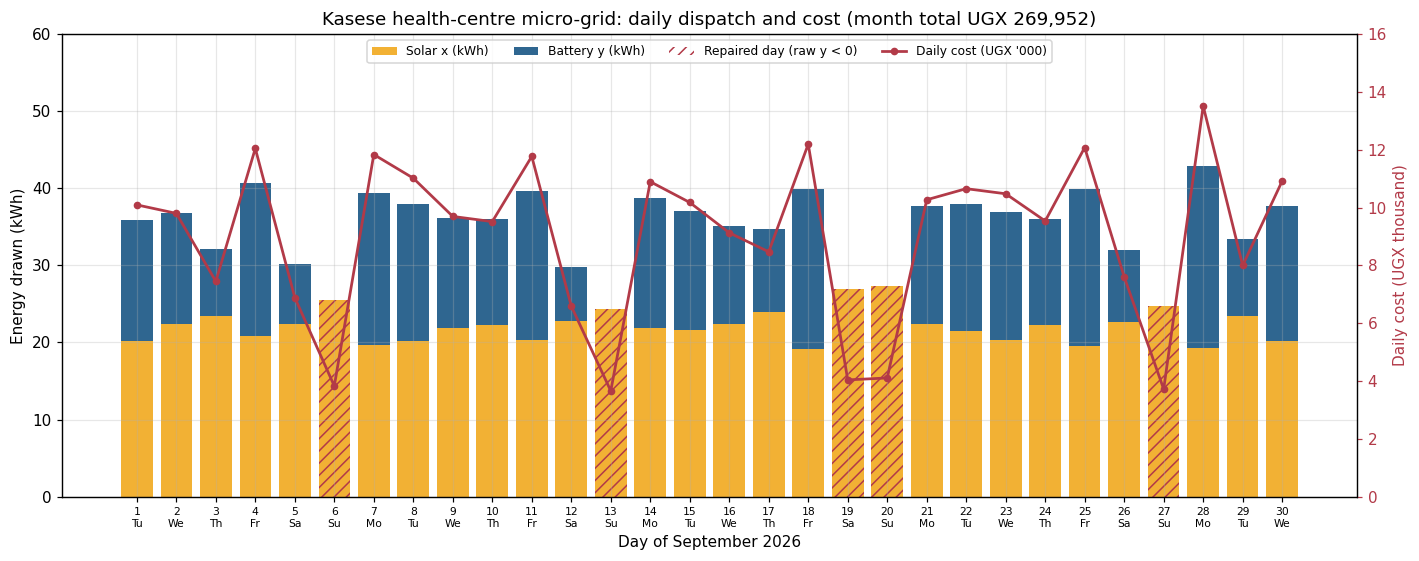

In [13]:
days = np.arange(1, len(demand) + 1)
fig, ax = plt.subplots(figsize=(13, 5.2))
ax.bar(days, plan["solar"], color="#F2B134", label="Solar x (kWh)")
ax.bar(days, plan["battery"], bottom=plan["solar"], color="#2F6690", label="Battery y (kWh)")
ax.bar(days[bad_days], plan["solar"][bad_days], fill=False, hatch="///", edgecolor="#B23A48", lw=0,
       label="Repaired day (raw y < 0)")
ax.set(xlabel="Day of September 2026", ylabel="Energy drawn (kWh)", xticks=days)
ax.set_xticklabels([f"{d}\n{w[0:2]}" for d, w in zip(days, demand.weekdays)], fontsize=7)
ax.set_ylim(0, 60)

ax2 = ax.twinx()
ax2.plot(days, daily_cost / 1000, color="#B23A48", marker="o", ms=4, lw=1.8, label="Daily cost (UGX '000)")
ax2.set_ylabel("Daily cost (UGX thousand)", color="#B23A48")
ax2.tick_params(axis="y", colors="#B23A48"); ax2.grid(False); ax2.set_ylim(0, 16)

h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, 1.0))
ax.set_title(f"Kasese health-centre micro-grid: daily dispatch and cost (month total UGX {monthly:,.0f})")
fig.tight_layout(); fig.savefig("figures/p2_dispatch_cost.png", bbox_inches="tight")
plt.show()

The cost line tracks the **battery** bars, not the total height. Solar varies little from day to day, so battery use at three times the unit price drives both the level and the weekly rhythm of cost: weekdays (Mon–Fri) ≈ UGX 10,500 and Sundays ≈ UGX 3,800. The hatched days are the repaired Sundays (plus 19 September), where the grid runs on solar alone.

## Extension A — `HybridMicroGrid`: adding a diesel generator

I add diesel $z$ and a **night-time constraint**. After dark solar cannot contribute, so only the battery and diesel serve the night load $D_3$:

$$3x + 2y + z = D_1,\qquad 4x + y + 2z = D_2,\qquad 0x + y + z = D_3.$$

`HybridMicroGrid` inherits everything from `MicroGrid` (validation, well-posedness, vectorised solving, repair strategies, costs, sensitivity). It only changes the defaults and adds two methods that matter for 3×3 systems: `classify()` (rank test) and `solve_least_squares()`. Night load is simulated as 38 kWh ± 5 %.

In [14]:
hybrid = HybridMicroGrid()
print(hybrid, "| is a MicroGrid:", isinstance(hybrid, MicroGrid))
d3 = np.round(38 * (1 + rng.normal(0, 0.05, len(demand))), 2)
rhs3 = np.vstack([rhs, d3])
hplan = hybrid.dispatch(rhs3)
print(f"Infeasible days in the hybrid system: {len(hplan.infeasible_days)}")
hsum = pd.DataFrame(hplan.adjusted.T, columns=hybrid.sources).describe().loc[["mean", "std", "min", "max"]]
hsum

HybridMicroGrid(sources=['solar', 'battery', 'diesel'], det=-7, cond=6.54) | is a MicroGrid: True
Infeasible days in the hybrid system: 0


,solar,battery,diesel
mean,11.13,19.10,18.90
std,1.54,6.81,6.20
min,7.44,0.14,12.12
max,13.06,28.44,35.25


In [15]:
hcost = hybrid.daily_cost(hplan.adjusted)
print(f"Hybrid monthly cost: UGX {hcost.sum():,.0f} vs 2-source UGX {monthly:,.0f} "
      f"(the hybrid also serves the night load D3, so this is not like-for-like)")
print(f"Diesel share of hybrid cost: {(1200 * hplan['diesel']).sum() / hcost.sum():.0%}")

Hybrid monthly cost: UGX 988,161 vs 2-source UGX 269,952 (the hybrid also serves the night load D3, so this is not like-for-like)
Diesel share of hybrid cost: 69%


With a third, independent source there are **no infeasible days**. On Sundays diesel (not a negative battery) absorbs the imbalance, rising to ≈ 30–35 kWh. That is the operational point of a hybrid system, but it is expensive: the monthly bill is several times higher, partly because the model now also serves a night load that the two-source model ignored. The two totals are therefore not directly comparable.

### What if the new equation is linearly dependent?
Suppose the third row is the sum of the first two, $7x + 3y + 3z = D_3$. It then adds no new information.

In [16]:
dep = HybridMicroGrid.with_dependent_constraint((1, 1))
print("A =\n", dep.coefficients)
print(f"det = {dep.determinant:.2e}, rank = {dep.rank}, cond = {dep.condition_number:.2e}")

for label, d in [("consistent  (D3 = D1 + D2)", (95, 100, 195)), ("contradictory (D3 = 40)", (95, 100, 40))]:
    kind = dep.classify(*d)
    sol, resid = dep.solve_least_squares(*d)
    print(f"\n{label}: solutions = {kind}")
    print(f"  min-norm least-squares answer {sol.round(2)}, residual norm {resid:.3g}")

try:
    dep.solve_day(95, 100, 195)
except SingularSystemError as err:
    print("\nsolve_day refuses:", err)

A =
 [[3. 2. 1.]
 [4. 1. 2.]
 [7. 3. 3.]]
det = 1.11e-15, rank = 2, cond = 2.52e+16

consistent  (D3 = D1 + D2): solutions = infinitely many
  min-norm least-squares answer [18.55 17.63  4.08], residual norm 1.42e-14

contradictory (D3 = 40): solutions = none
  min-norm least-squares answer [9.04 6.75 2.72], residual norm 89.5

solve_day refuses: Matrix rank 2 < 3 (det=1.11e-15): the constraints are linearly dependent, so there is no unique dispatch.


Once a row is a combination of the others, $\det A = 0$ (printed as ≈ 10⁻¹⁵, which is zero up to floating-point rounding), the rank drops to 2 and the condition number blows up (≈ 10¹⁶, i.e. numerically infinite). By the Rouché–Capelli theorem, there are only two possibilities:

* **Consistent demands** ($D_3 = D_1 + D_2$): rank$[A]$ = rank$[A\,|\,d]$ = 2 < 3, so there are **infinitely many** dispatches, forming a line in $(x, y, z)$ space. The grid has one free degree of freedom, and the operator must add a rule (e.g. cheapest cost) to pick one. `lstsq` returns the minimum-norm point, which is mathematically neat but has no cost logic.
* **Contradictory demands**: rank$[A\,|\,d]$ = 3 > 2, so there is **no solution** at all; least squares returns the closest compromise with a non-zero residual.

This is why `solve_day` checks the rank *before* solving: `scipy.linalg.solve` would otherwise raise an error, or, for a *nearly* dependent row, silently return huge meaningless numbers.

## Extension B — Monte Carlo sensitivity (±5 %, 1,000 draws)

In [17]:
base = rhs.mean(axis=1)             # an average day
sens = grid.sensitivity(base, rel_perturbation=0.05, n_draws=1000, seed=SEED)
lo, hi = np.percentile(sens.solutions, [2.5, 97.5], axis=0)
sens_table = pd.DataFrame({
    "base (kWh)": sens.base_solution, "std (kWh)": sens.solutions.std(axis=0, ddof=1),
    "2.5%": lo, "97.5%": hi,
    "95% range as % of base": 100 * (hi - lo) / sens.base_solution,
}, index=grid.sources)
print(f"Base demand D = {base.round(2)}")
sens_table

Base demand D = [ 90.47 101.4 ]


,base (kWh),std (kWh),2.5%,97.5%,95% range as % of base
solar,22.46,1.28,20.20,24.73,20.15
battery,11.54,2.73,6.38,16.62,88.79


In [18]:
amp = sens.amplification
print(f"Mean relative change in demand   : {sens.rel_input_change.mean():.2%}")
print(f"Mean relative change in solution : {sens.rel_output_change.mean():.2%}")
print(f"Amplification: median {np.median(amp):.2f}, max {amp.max():.3f}, condition number {grid.condition_number:.3f}")
assert amp.max() <= grid.condition_number + 1e-9     # the theoretical bound holds

sunday = rhs[:, 5]
sens_sun = grid.sensitivity(sunday, 0.05, 1000, SEED)
print(f"\nSunday 6 Sep (D = {sunday}): share of draws with negative battery = {(sens_sun.solutions[:, 1] < 0).mean():.0%}")

Mean relative change in demand   : 2.70%
Mean relative change in solution : 10.20%
Amplification: median 4.15, max 5.809, condition number 5.828

Sunday 6 Sep (D = [ 67.6  102.05]): share of draws with negative battery = 100%


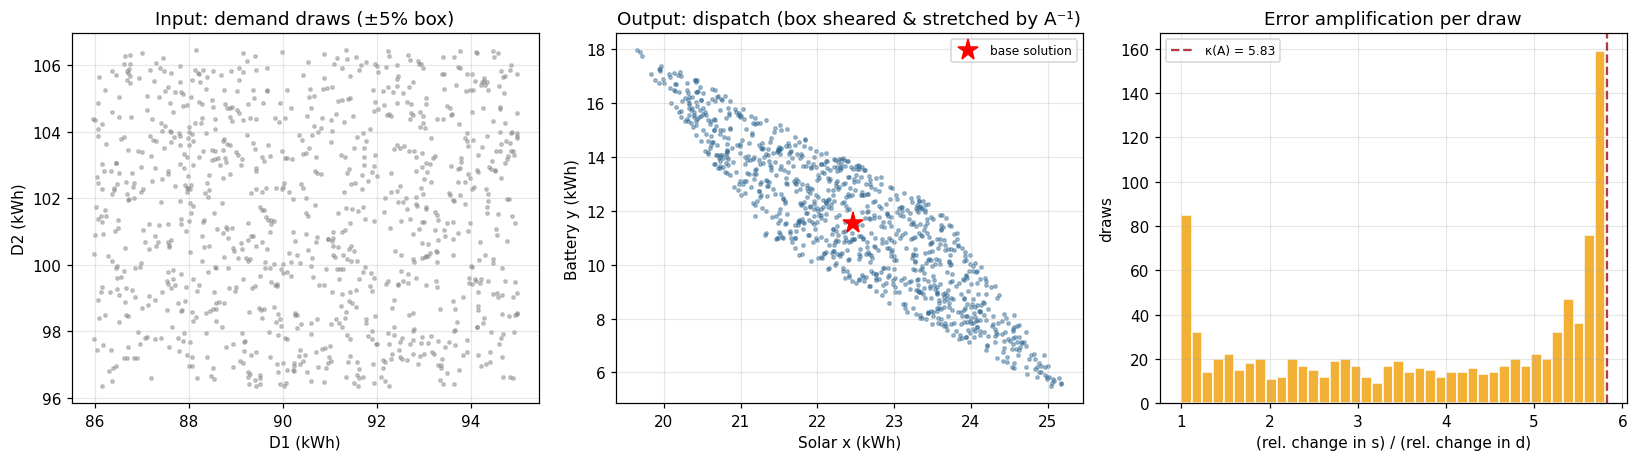

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
axes[0].scatter(sens.demands[:, 0], sens.demands[:, 1], s=5, alpha=0.4, color="grey")
axes[0].set(title="Input: demand draws (±5% box)", xlabel="D1 (kWh)", ylabel="D2 (kWh)")
axes[1].scatter(sens.solutions[:, 0], sens.solutions[:, 1], s=5, alpha=0.4, color="#2F6690")
axes[1].plot(*sens.base_solution, "r*", ms=14, label="base solution")
axes[1].set(title="Output: dispatch (box sheared & stretched by A⁻¹)", xlabel="Solar x (kWh)", ylabel="Battery y (kWh)")
axes[1].legend(fontsize=8)
axes[2].hist(amp, bins=40, color="#F2B134", edgecolor="white")
axes[2].axvline(grid.condition_number, color="#B23A48", ls="--", label=f"κ(A) = {grid.condition_number:.2f}")
axes[2].set(title="Error amplification per draw", xlabel="(rel. change in s) / (rel. change in d)", ylabel="draws")
axes[2].legend(fontsize=8)
fig.tight_layout(); fig.savefig("figures/p2_sensitivity.png", bbox_inches="tight")
plt.show()

A ±5 % wobble in demand moves solar by about ±10 % but the **battery by about ±45 %** (95 % range relative to its base). The input box of demands is mapped by $A^{-1}$ into a sheared, stretched parallelogram. It is stretched most along the battery axis, the direction of the smallest singular value of $A$.

The empirical amplification never exceeds κ(A) ≈ 5.83; the worst draw reaches ≈ 5.81, so the bound is essentially attained. The typical (median) amplification is ≈ 4. The practical consequence shows up on low-ratio days. On Sunday 6 September, *every* perturbed draw still requires negative battery use: small forecasting errors cannot rescue an infeasible day, and on marginal days they can easily tip a feasible plan into an infeasible one. A condition number of 5.8 is "well-conditioned" numerically, yet still large enough to matter operationally for the battery.

## Findings & Limitations

**Findings.** The 2×2 system is well-posed (det = −5, κ ≈ 5.8), so every day has a unique, numerically reliable solution. Five of 30 days — every Sunday and one high-critical-load Saturday — were nonetheless *physically* infeasible. Cramer's rule shows why: a non-negative dispatch exists only when $0.75 \le D_1/D_2 \le 2$, and on quiet days the clinic's daytime load falls below 75 % of the round-the-clock critical load. The repair strategy is a policy decision, not a technicality. NNLS was cheapest but left ≈ 19 kWh of critical load unmet, so I chose a least-cost cover (linear programme) that never under-supplies critical equipment. The battery is the volatile, expensive source: its CV is ≈ 55 % against ≈ 10 % for solar, and at three times the unit price it sets both the level and the weekly rhythm of the ≈ UGX 270,000 monthly bill. Sensitivity analysis confirmed the theory — demand errors were amplified up to κ, and almost entirely into battery draw. Vectorising the solve was an order of magnitude faster because it removes per-call overhead, not arithmetic.

**Limitations.** The demand data are synthetic, and the coefficients are a stylised model rather than engineering parameters. The model has no time dimension: battery state of charge, charging from surplus solar, capacity limits and weather-driven solar availability are all ignored, although these are exactly what a real dispatch plan must respect. Treating negative battery draw as "infeasible" rather than as charging is a modelling choice. The diesel constraint is my own design, so the hybrid costs are not comparable with the two-source costs. Costs are illustrative. A realistic next step is an hour-by-hour linear programme with storage dynamics, driven by NASA POWER irradiance for Kasese.